import the libraries used for developing this fruad detecting algorithm 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder as le
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

read the csv file 

In [ ]:
insurance_data= pd.read_csv('/content/drive/MyDrive/colab projects/Detecting fraud in insurance claims/insurance_claims.csv')

About Import dataset 

In [ ]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [ ]:
insurance_data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [ ]:
insurance_data.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


Feature selecting and extracting 

In [ ]:
insurance_data.drop('_c39',axis=1, inplace=True)
# searching for any missing values within the coloum
insurance_data.isnull().sum()

months_as_customer             0
age                            0
policy_number                  0
policy_bind_date               0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_zip                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
insured_relationship           0
capital-gains                  0
capital-loss                   0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_location              0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
witnesses                      0
police_rep

Use Label encoder to extract more features from the dataset 

In [ ]:
count=0
le=le()
for col in insurance_data:
  if insurance_data[col].dtype == 'object':
    if len(list(insurance_data[col].unique())) <=2 :
      le.fit(insurance_data[col])
      insurance_data[col]= le.transform(insurance_data[col])
      count +=1
    else:
       insurance_data.drop([col],axis=1, inplace=True)
print (" Number of Colums coverter with Label_encoder %d" %count)

 Number of Colums coverter with Label_encoder 2


Number of Fraud reported within the dataset 

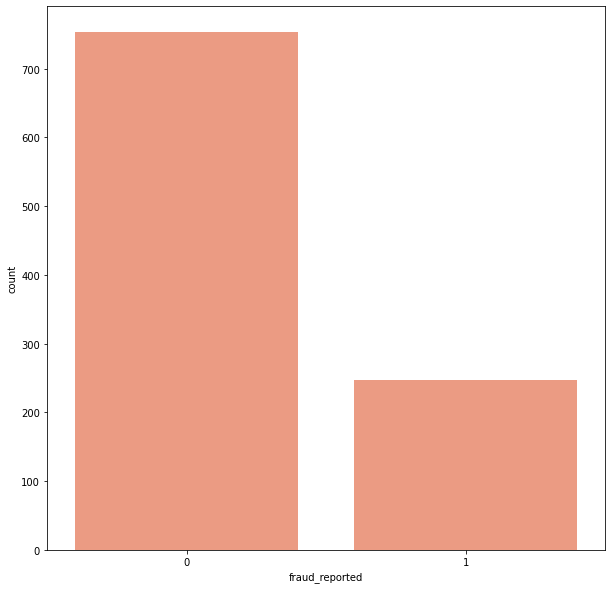

In [ ]:
insurance_data.shape
f, ax = plt.subplots(figsize=(10, 10))
sns.countplot(x='fraud_reported',data=insurance_data, color= '#fc9272')

use train test function to split and train the dataset

In [ ]:
X_value = insurance_data.drop('fraud_reported', axis = 1)
y_value = insurance_data['fraud_reported']
y_value = le.fit_transform(y_value)
X_train, X_test, y_train, y_test = train_test_split(X_value,y_value, test_size= 0.2, random_state=101)
print('The shape of X_train is: {}'.format(X_train.shape))
print('The shape of X_test is: {}'.format(X_test.shape))
print('The shape of y_train is: {}'.format(y_train.shape))
print('The shape of y_test is: {}'.format(y_test.shape))

The shape of X_train is: (800, 19)
The shape of X_test is: (200, 19)
The shape of y_train is: (800,)
The shape of y_test is: (200,)


train with supervised learning 

logistic regression

In [ ]:
model = LogisticRegression()
model.fit(X_train,y_train)
pred_train = model.predict(X_train)

# Summary of the predictions made by the classifier
print(classification_report(y_train,pred_train))
print(confusion_matrix(y_train,pred_train))

# Accuracy score
print('Accuracy Score of Model on train data is: {}' .format(accuracy_score(y_train,pred_train)))

#on test data
pred_test = model.predict(X_test)
# Summary of the predictions made by the classifier
print(classification_report(y_test,pred_test))
print(confusion_matrix(y_test,pred_test))

# Accuracy score
print('Accuracy Score of Model on test data is: {}' .format(accuracy_score(y_test,pred_test)))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85       593
           1       0.33      0.00      0.01       207

    accuracy                           0.74       800
   macro avg       0.54      0.50      0.43       800
weighted avg       0.64      0.74      0.63       800

[[591   2]
 [206   1]]
Accuracy Score of Model on train data is: 0.74
              precision    recall  f1-score   support

           0       0.81      1.00      0.89       160
           1       1.00      0.05      0.10        40

    accuracy                           0.81       200
   macro avg       0.90      0.53      0.49       200
weighted avg       0.85      0.81      0.73       200

[[160   0]
 [ 38   2]]
Accuracy Score of Model on test data is: 0.81


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


decision tree 

In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

pred_train = model.predict(X_train)
print(classification_report(y_train,pred_train))
print(confusion_matrix(y_train,pred_train))

# Accuracy score
print('Accuracy Score of Model on train data is: {}' .format(accuracy_score(y_train,pred_train)))

pred_test = model.predict(X_test)
print(classification_report(y_test,pred_test))
print(confusion_matrix(y_test,pred_test))

# Accuracy score
print('Accuracy Score of Model on test data is: {}' .format(accuracy_score(y_test,pred_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       593
           1       1.00      1.00      1.00       207

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

[[593   0]
 [  0 207]]
Accuracy Score of Model on train data is: 1.0
              precision    recall  f1-score   support

           0       0.79      0.72      0.75       160
           1       0.17      0.23      0.19        40

    accuracy                           0.62       200
   macro avg       0.48      0.47      0.47       200
weighted avg       0.66      0.62      0.64       200

[[115  45]
 [ 31   9]]
Accuracy Score of Model on test data is: 0.62


SVM

In [ ]:
model = SVC()
model.fit(X_train,y_train)
pred_train = model.predict(X_train)
# Summary of the predictions made by the classifier
print(classification_report(y_train,pred_train))
print(confusion_matrix(y_train,pred_train))

# Accuracy score
print('Accuracy Score of Model on train data is: {}' .format(accuracy_score(y_train,pred_train)))
pred_test = model.predict(X_test)
# Summary of the predictions made by the classifier
print(classification_report(y_test,pred_test))
print(confusion_matrix(y_test,pred_test))

# Accuracy score
print('Accuracy Score of Model on test data is: {}' .format(accuracy_score(y_test,pred_test)))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85       593
           1       0.00      0.00      0.00       207

    accuracy                           0.74       800
   macro avg       0.37      0.50      0.43       800
weighted avg       0.55      0.74      0.63       800

[[593   0]
 [207   0]]
Accuracy Score of Model on train data is: 0.74125
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       160
           1       0.00      0.00      0.00        40

    accuracy                           0.80       200
   macro avg       0.40      0.50      0.44       200
weighted avg       0.64      0.80      0.71       200

[[160   0]
 [ 40   0]]
Accuracy Score of Model on test data is: 0.8


/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classificat

with un-supervised learning 

k-means clustering

In [ ]:
model = KNeighborsClassifier(n_neighbors=8)
model.fit(X_train,y_train)
pred_train = model.predict(X_train)
# Summary of the predictions made by the classifier
print(classification_report(y_train,pred_train))
print(confusion_matrix(y_train,pred_train))

# Accuracy score
print('Accuracy Score of Model on train data is: {}' .format(accuracy_score(y_train,pred_train)))
pred_test = model.predict(X_test)
# Summary of the predictions made by the classifier
print(classification_report(y_test,pred_test))
print(confusion_matrix(y_test,pred_test))

# Accuracy score
print('Accuracy Score of Model on test data is: {}' .format(accuracy_score(y_test,pred_test)))

              precision    recall  f1-score   support

           0       0.75      0.99      0.85       593
           1       0.71      0.05      0.09       207

    accuracy                           0.75       800
   macro avg       0.73      0.52      0.47       800
weighted avg       0.74      0.75      0.66       800

[[589   4]
 [197  10]]
Accuracy Score of Model on train data is: 0.74875
              precision    recall  f1-score   support

           0       0.81      0.98      0.88       160
           1       0.40      0.05      0.09        40

    accuracy                           0.80       200
   macro avg       0.60      0.52      0.49       200
weighted avg       0.72      0.80      0.73       200

[[157   3]
 [ 38   2]]
Accuracy Score of Model on test data is: 0.795


gaussian Mixture 

In [ ]:
model = GaussianNB()
model.fit(X_train,y_train)
pred_train = model.predict(X_train)
print(classification_report(y_train,pred_train))
print(confusion_matrix(y_train,pred_train))

# Accuracy score
print('Accuracy Score of Model on train data is: {}' .format(accuracy_score(y_train,pred_train)))

pred_test = model.predict(X_test)
print(classification_report(y_test,pred_test))
print(confusion_matrix(y_test,pred_test))

# Accuracy score
print('Accuracy Score of Model on test data is: {}' .format(accuracy_score(y_test,pred_test)))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78       593
           1       0.34      0.29      0.31       207

    accuracy                           0.67       800
   macro avg       0.55      0.54      0.55       800
weighted avg       0.65      0.67      0.66       800

[[474 119]
 [147  60]]
Accuracy Score of Model on train data is: 0.6675
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       160
           1       0.24      0.28      0.26        40

    accuracy                           0.68       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.70      0.68      0.69       200

[[125  35]
 [ 29  11]]
Accuracy Score of Model on test data is: 0.68
